In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

df = pd.read_csv('../data/clean/sales_data.csv')

TARGETS = {
    'hh_value':    28.50,
    'bb_conv':     0.1800,
    'mob_conv':    0.1420,
    'tv_conv':     0.0580,
    'combined_conv': 0.3220
}

df['total_new_sales'] = df['broadband'] + df['mobile'] + df['tv']
df['total_transactions'] = df['broadband'] + df['mobile'] + df['tv'] + df['regrades']

monthly = df.groupby('team').agg(
    total_calls=('calls', 'sum'),
    total_broadband=('broadband', 'sum'),
    total_mobile=('mobile', 'sum'),
    total_tv=('tv', 'sum'),
    total_hh_orders=('hh_orders', 'sum'),
    total_hh_value=('hh_value', 'sum'),
    total_transactions=('total_transactions', 'sum'),
).reset_index()

monthly['bb_conv']        = monthly['total_broadband'] / monthly['total_calls']
monthly['mob_conv']       = monthly['total_mobile']    / monthly['total_calls']
monthly['tv_conv']        = monthly['total_tv']        / monthly['total_calls']
monthly['combined_conv']  = (monthly['total_broadband'] + monthly['total_mobile']) / monthly['total_calls']
monthly['avg_hh_value']   = monthly['total_hh_value']  / monthly['total_hh_orders']
monthly['products_per_hh']= monthly['total_transactions'] / monthly['total_hh_orders']
monthly['value_per_call'] = monthly['total_hh_value']  / monthly['total_calls']

print("Monthly data ready.")
print(monthly[['team', 'bb_conv', 'mob_conv', 'avg_hh_value', 'products_per_hh', 'value_per_call']])

Monthly data ready.
             team   bb_conv  mob_conv  avg_hh_value  products_per_hh  \
0      Ben Traill  0.183502  0.157036     37.618699         2.573980   
1    Beth Ogilvie  0.165509  0.159823     31.337117         1.486708   
2     Jack Inglis  0.156791  0.126377     28.889217         1.240214   
3  Joel Robertson  0.162562  0.119458     29.089458         1.293454   
4    Paula Wilson  0.149185  0.150108     35.057163         1.673554   
5    Reece Wright  0.168609  0.149459     47.873815         4.397590   
6       Ryan Watt  0.182153  0.171460     32.924401         1.478111   
7    Scott Brodie  0.151751  0.166018     30.624279         1.347826   

   value_per_call  
0        6.504865  
1        9.680259  
2        8.513760  
3        7.935117  
4        7.828822  
5        4.962773  
6       10.537751  
7        8.678865  


In [2]:
# Conversion rates and value metrics rather than raw volumes
# Clustering by HOW teams sell, not just HOW MUCH they sell
features = ['bb_conv', 'mob_conv', 'tv_conv', 'avg_hh_value', 'products_per_hh', 'value_per_call']

X = monthly[features].copy()
team_names = monthly['team'].values

# Standardise features so no single metric dominates due to scale differences
# eg - avg_hh_value is in £ while conv rates are small decimals
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Features selected for clustering:")
for f in features:
    print(f"  - {f}")
print(f"\nScaled feature matrix shape: {X_scaled.shape}")

Features selected for clustering:
  - bb_conv
  - mob_conv
  - tv_conv
  - avg_hh_value
  - products_per_hh
  - value_per_call

Scaled feature matrix shape: (8, 6)


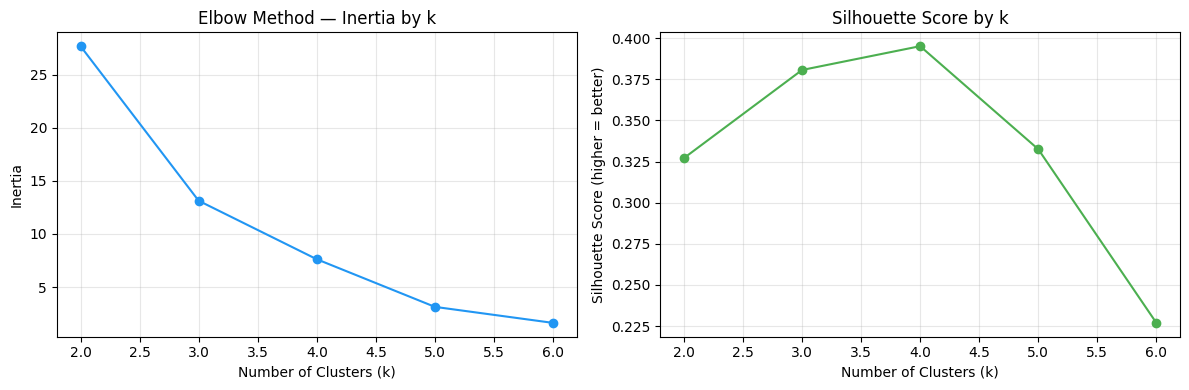


Silhouette scores:
  k=2: 0.327
  k=3: 0.381
  k=4: 0.395
  k=5: 0.332
  k=6: 0.227


In [3]:
# Two methods to find the best k:
# 1. Inertia (elbow method) - measures how tight the clusters are
# 2. Silhouette score - measures how well separated the clusters are

inertias = []
silhouette_scores = []
k_range = range(2, 7)  # 6 clusters for 8 teams 

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(k_range, inertias, marker='o', color='#2196F3')
axes[0].set_title('Elbow Method — Inertia by k')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].grid(alpha=0.3)

axes[1].plot(k_range, silhouette_scores, marker='o', color='#4CAF50')
axes[1].set_title('Silhouette Score by k')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score (higher = better)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../data/clean/cluster_selection.png', dpi=150)
plt.show()

print("\nSilhouette scores:")
for k, s in zip(k_range, silhouette_scores):
    print(f"  k={k}: {s:.3f}")

In [4]:
# With only 8 teams, 3 clusters is optimal
# Adjusted after silhouette scores
CHOSEN_K = 3

kmeans = KMeans(n_clusters=CHOSEN_K, random_state=42, n_init=10)
monthly['cluster'] = kmeans.fit_predict(X_scaled)

print("Cluster assignments:")
print(monthly[['team', 'cluster', 'bb_conv', 'mob_conv', 'avg_hh_value', 
               'products_per_hh', 'value_per_call']].sort_values('cluster'))

Cluster assignments:
             team  cluster   bb_conv  mob_conv  avg_hh_value  products_per_hh  \
1    Beth Ogilvie        0  0.165509  0.159823     31.337117         1.486708   
6       Ryan Watt        0  0.182153  0.171460     32.924401         1.478111   
3  Joel Robertson        1  0.162562  0.119458     29.089458         1.293454   
2     Jack Inglis        1  0.156791  0.126377     28.889217         1.240214   
7    Scott Brodie        1  0.151751  0.166018     30.624279         1.347826   
4    Paula Wilson        1  0.149185  0.150108     35.057163         1.673554   
0      Ben Traill        2  0.183502  0.157036     37.618699         2.573980   
5    Reece Wright        2  0.168609  0.149459     47.873815         4.397590   

   value_per_call  
1        9.680259  
6       10.537751  
3        7.935117  
2        8.513760  
7        8.678865  
4        7.828822  
0        6.504865  
5        4.962773  


In [9]:
# Calculate the mean of each feature per cluster to understand what each represents
cluster_profiles = monthly.groupby('cluster')[features].mean()
print("Cluster profiles (mean values per cluster):")
print(cluster_profiles.round(4))

# After seeing the output above, we'll assign meaningful labels
# These may need updating based on what the data shows
cluster_labels = {
    0: 'Efficient Conversions',
    1: 'Core Performers',
    2: 'High Bundles'
}

monthly['cluster_label'] = monthly['cluster'].map(cluster_labels)
print("\nTeams per cluster:")
for label in monthly['cluster_label'].unique():
    teams = monthly[monthly['cluster_label'] == label]['team'].tolist()
    print(f"  {label}: {teams}")

Cluster profiles (mean values per cluster):
         bb_conv  mob_conv  tv_conv  avg_hh_value  products_per_hh  \
cluster                                                              
0         0.1738    0.1656   0.0695       32.1308           1.4824   
1         0.1551    0.1405   0.0429       30.9150           1.3888   
2         0.1761    0.1532   0.0591       42.7463           3.4858   

         value_per_call  
cluster                  
0               10.1090  
1                8.2391  
2                5.7338  

Teams per cluster:
  High Bundles: ['Ben Traill', 'Reece Wright']
  Efficient Conversions: ['Beth Ogilvie', 'Ryan Watt']
  Core Performers: ['Jack Inglis', 'Joel Robertson', 'Paula Wilson', 'Scott Brodie']


## Cluster Interpretation

K-means clustering with k=3 (chosen based on silhouette score and 
interpretability given n=8 teams) identified three distinct performance profiles:

**Efficient Conversions** (Beth Ogilvie, Ryan Watt)
Highest value per call in the centre. These teams are converting calls 
into revenue most efficiently. Ryan Watt leads the centre in total HH value 
partly because of this efficiency combined with high call volume.

**Core Performers** (Joel Robertson, Jack Inglis, Scott Brodie, Paula Wilson)
The largest cluster. Solid across all metrics but no standout dimension. 
Paula Wilson's volume masks efficiency metrics that place her here rather 
than in the top cluster — suggesting significant upside if her bundling 
rate can be improved.

**High Bundles** (Ben Traill, Reece Wright)
Exceptional at maximising value per household — Reece Wright's products 
per HH of 4.40 is the highest in the centre by a wide margin. However, 
lower value per call suggests fewer successful household conversions per 
call taken. A coaching focus on call conversion volume could unlock 
significant additional revenue for this cluster.

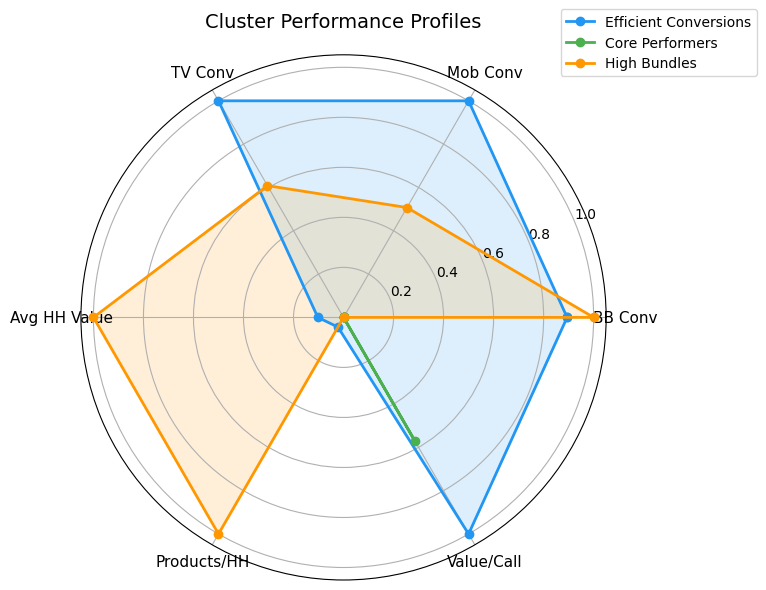

In [12]:
from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as mpatches

# Normalise cluster profiles to 0-1 for radar chart display
profile_norm = (cluster_profiles - cluster_profiles.min()) / (cluster_profiles.max() - cluster_profiles.min())

categories = ['BB Conv', 'Mob Conv', 'TV Conv', 'Avg HH Value', 'Products/HH', 'Value/Call']
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]  # close the polygon

colors = ['#2196F3', '#4CAF50', '#FF9800']

cluster_names = {
    0: 'Efficient Conversions',
    1: 'Core Performers',
    2: 'High Bundles'
}

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for i, (idx, row) in enumerate(profile_norm.iterrows()):
    values = row.tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, color=colors[i], label=cluster_names[idx])
    ax.fill(angles, values, alpha=0.15, color=colors[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, size=11)
ax.set_title('Cluster Performance Profiles', size=14, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
ax.grid(True)

plt.tight_layout()
plt.savefig('../data/clean/cluster_radar.png', dpi=150)
plt.show()

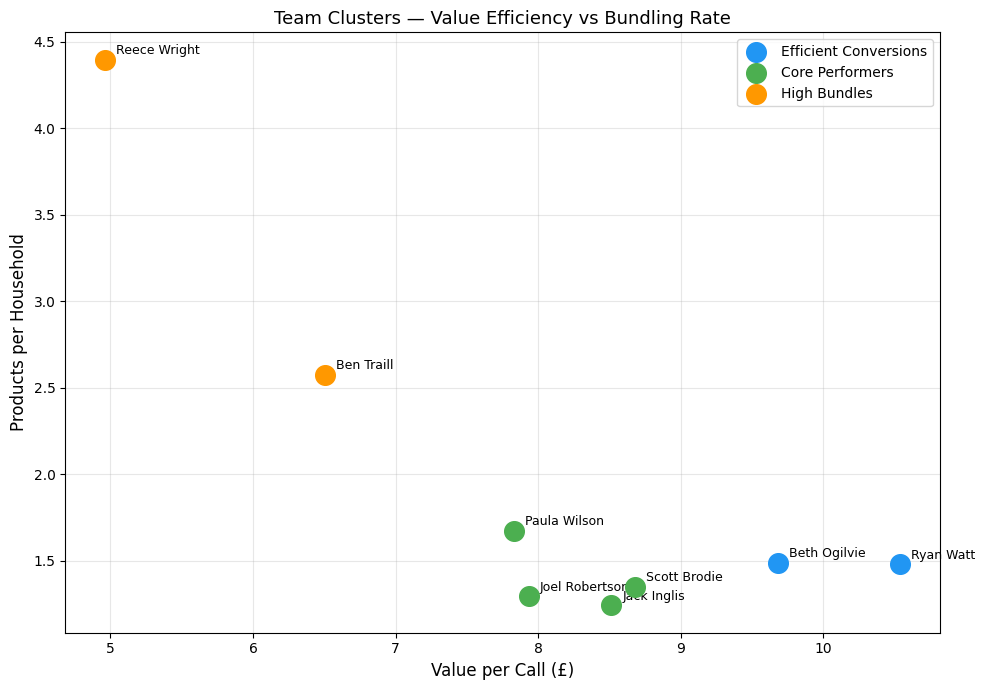

In [14]:
# Plot teams in 2D using value_per_call vs products_per_hh
# These two metrics best capture the volume/value distinction we identified in EDA

fig, ax = plt.subplots(figsize=(10, 7))

for cluster_id in sorted(monthly['cluster'].unique()):
    mask = monthly['cluster'] == cluster_id
    ax.scatter(
        monthly[mask]['value_per_call'],
        monthly[mask]['products_per_hh'],
        s=200,
        color=colors[cluster_id],
        label=cluster_names[cluster_id],
        zorder=5
    )
    for _, row in monthly[mask].iterrows():
        ax.annotate(
            row['team'],
            (row['value_per_call'], row['products_per_hh']),
            textcoords='offset points',
            xytext=(8, 4),
            fontsize=9
        )

ax.set_xlabel('Value per Call (£)', fontsize=12)
ax.set_ylabel('Products per Household', fontsize=12)
ax.set_title('Team Clusters — Value Efficiency vs Bundling Rate', fontsize=13)
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../data/clean/cluster_scatter.png', dpi=150)
plt.show()

Reece Wright is a genuine outlier — sitting completely alone in the top left with the highest bundling rate but lowest value per call. Ben Traill sits between the clusters which makes sense given he's a high bundler but more moderate than Reece.
The Efficient Converters (blue — Ryan Watt and Beth Ogilvie) are clearly separated to the right, confirming they generate more revenue per call than anyone else.
The Core Performers (green) cluster tightly in the middle, which is exactly what you'd expect.
This chart alone could anchor a coaching conversation — the x-axis tells you call efficiency, the y-axis tells you bundling behaviour, and the quadrant a team sits in tells you exactly what to focus on.